# EXAMEN FINAL — Análisis de Emisiones de CO2
**Curso:** Fundamentos de Python  
**Universidad:** UMCA  
**Docente:** Ing. Andrés Mena Abarca
- **Estudiante:** Cristopher Mora Rodriguez

## Archivo de trabajo
`Estimaciones_Emisiones_Dioxido_Carbono.csv`

## Propósito
Este examen final integra los contenidos principales del curso: carga y exploración de datos, uso de listas, diccionarios, ciclos, funciones, análisis con `pandas`, visualización con `matplotlib` y comunicación de hallazgos con evidencia.


## Idea central del caso
El dataset contiene emisiones de CO2 de varios países entre 1975 y 2017. Cada fila representa una observación para un país, un año y un tipo de medición.

Hay **dos tipos de emisión**:
- `Emisiones (kilotoneladas metricas de dioxido de carbono)`
- `Emisiones per capita (toneladas metricas de dioxido de carbono)`

### Atención
Estas dos métricas **no significan lo mismo**. Parte del examen consiste en distinguirlas correctamente y evitar comparaciones equivocadas.


## Entregables esperados
1. Código funcional y ordenado.
2. Evidencia de comprensión del dataset.
3. Uso de **4 funciones obligatorias** creadas por ti.
4. Resolución de un bloque con Python base.
5. Resolución de un bloque con `pandas`.
6. Dos gráficos correctamente rotulados.
7. Un informe final crítico con evidencia numérica.


## Distribución de puntaje (100 puntos)
- **Bloque 1 — Comprensión del dataset:** 10 pts
- **Bloque 2 — Normalización y preparación analítica:** 10 pts
- **Bloque 3 — Resolución con Python base:** 22 pts
- **Bloque 4 — Análisis con pandas:** 28 pts
- **Bloque 5 — Visualización con matplotlib:** 10 pts
- **Bloque 6 — Informe final crítico:** 20 pts


## Rúbrica por niveles de desempeño

### Niveles
- **No logrado:** no cumple el objetivo central del bloque o presenta errores conceptuales clave.
- **Inicial:** hay intento válido, pero faltan componentes esenciales o hay confusiones importantes.
- **Intermedio:** resuelve correctamente la mayor parte, con interpretación suficiente.
- **Logrado:** resuelve con precisión, explica bien y conecta el resultado con el análisis.

### Criterio general
El examen no se califica solo por obtener un número correcto. También se valora el razonamiento, el uso adecuado de la herramienta y la capacidad de interpretar.


In [1]:
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import pandas as pd

ARCHIVO = "Estimaciones_Emisiones_Dioxido_Carbono.csv"


---
## Bloque 1 — Comprensión del dataset (10 pts)

### Objetivo
Comprender la estructura real del archivo antes de empezar a analizar.

### Debes hacer exactamente esto
1. Cargar el CSV en un DataFrame llamado `df_raw`.
2. Mostrar:
   - `df_raw.shape`
   - lista de columnas
   - `df_raw.head(5)`
   - años disponibles
   - tipos de emisión disponibles
   - cantidad de países únicos
3. Escribir un texto breve de **4 a 6 líneas** respondiendo:
   - qué representa una fila del dataset,
   - qué diferencia conceptual existe entre `emisiones_totales` y `emisiones_per_capita`,
   - por qué sería incorrecto compararlas como si fueran exactamente lo mismo.

### Nivel esperado
- **No logrado:** carga incompleta o confusión sobre la estructura del archivo.
- **Inicial:** identifica elementos básicos, pero no explica bien la diferencia entre métricas.
- **Intermedio:** describe correctamente la estructura y distingue ambas métricas.
- **Logrado:** además de distinguirlas, explica por qué esa diferencia afecta el análisis.


In [2]:
# 1.1 Carga el archivo en un DataFrame llamado df_raw
df_raw = pd.read_csv(ARCHIVO)


In [3]:
# 2.0 Muestra shape, columnas, head(5), años disponibles, tipos de emisión y países únicos
print("Muestra las dimensiones")
print(df_raw.shape)

Muestra las dimensiones
(2132, 4)


In [4]:
#2.1 muestra lista de columnas del df_raw
print("Lista de columnas")
print(df_raw.columns.to_list())


Lista de columnas
['Country', 'Year', 'Type', 'Value']


In [5]:
#2.2 muestra head(5) del df_raw
print("Muestra las primeras 5 filas")
print(df_raw.head())

Muestra las primeras 5 filas
   Country  Year                                               Type     Value
0  Albania  1975  Emisiones (kilotoneladas metricas de dioxido d...  4338.334
1  Albania  1985  Emisiones (kilotoneladas metricas de dioxido d...  6929.926
2  Albania  1995  Emisiones (kilotoneladas metricas de dioxido d...  1848.549
3  Albania  2005  Emisiones (kilotoneladas metricas de dioxido d...  3825.184
4  Albania  2010  Emisiones (kilotoneladas metricas de dioxido d...  3930.295


In [6]:
#2.3 muestra anios disponibles
print("Años disponibles")
print(df_raw["Year"].unique())

Años disponibles
[1975 1985 1995 2005 2010 2015 2016 2017]


In [7]:
#2.4 tipos de emisión disponibles
print("Tipos de emisión disponibles en el df_raw:")
print(df_raw["Type"].unique())

Tipos de emisión disponibles en el df_raw:
<StringArray>
['Emisiones (kilotoneladas metricas de dioxido de carbono)', 'Emisiones per capita (toneladas metricas de dioxido de carbono)']
Length: 2, dtype: str


In [8]:
#2.5 cantidad de paises dispoonibles
print("Cantidad de paises unicos:")
print(df_raw["Country"].nunique())

Cantidad de paises unicos:
142


### Explicación conceptual del Bloque 1
Escribe aquí tu texto de 4 a 6 líneas.


Inicialmente se hace la carga del data frame desde el archivo .CSV, posteriormente se inicia con los pasos propuestos.
En el punto 2.0 se determinan las dimensiones del df,
En el punto 2.1 se muestra unicamente los nombres de las columnas del df.
En el punto 2.2 se muestran las primeras 5 columnas del df utilizando la funcion .head.
En el punto 2.3 se muetran los anios disponibles en el df a modo de lista de los mismos.
En el punto 2.4 se muetran las dos emisiones disponibles de manera textual.
En el punto 2.5 se muestran la cantidad de paises disponibles en el df.

En la parte inicial del examen hacemos un recorrido por la data que se va a utilizar, se revisa el tipo de data, valores y dimension de lo que vamos a trabajar.

---
## Bloque 2 — Normalización y preparación analítica (10 pts)

### Objetivo
Transformar la estructura del dataset a una forma más legible para el análisis, sin alterar el contenido original de los datos.

### Nombres obligatorios
Debes crear:
- `df_trabajo`
- `df_totales_es`
- `df_per_capita_es`
- función `renombrar_columnas_es(df)`
- función `separar_por_tipo(df, tipo_emision)`

### Requisitos exactos
1. Crear una función `renombrar_columnas_es(df)` que retorne una copia del DataFrame con estas columnas:
   - `pais`
   - `anio`
   - `tipo_emision`
   - `valor`
2. Aplicar esa función y guardar el resultado en `df_trabajo`.
3. Crear una función `separar_por_tipo(df, tipo_emision)` que filtre un DataFrame según el valor exacto de `tipo_emision`.
4. Crear:
   - `df_totales_es`
   - `df_per_capita_es`
5. Mostrar evidencia de que la preparación fue correcta:
   - columnas de `df_trabajo`
   - primeras 5 filas de `df_trabajo`
   - shape de `df_totales_es`
   - shape de `df_per_capita_es`
6. Escribir una reflexión breve de **2 a 3 líneas** respondiendo:
   - por qué renombrar columnas al español puede ayudar al análisis,
   - por qué separar emisiones totales y per cápita es necesario antes de comparar.

### Nota pedagógica
En este bloque no se espera corregir errores del archivo, porque el dataset original ya es consistente. Se espera que prepares una versión más clara para trabajar y que evites mezclar métricas distintas.

### Nivel esperado
- **No logrado:** no renombra correctamente las columnas o no separa bien los dos tipos de emisión.
- **Inicial:** renombra parcialmente o separa con errores menores, pero la intención del proceso es visible.
- **Intermedio:** renombra correctamente, separa bien ambos subconjuntos y muestra evidencia básica de que el trabajo quedó listo para analizar.
- **Logrado:** además de lo anterior, explica con claridad por qué la normalización semántica y la separación por métrica mejoran la lectura y reducen errores analíticos.


In [9]:
#Crear cobstantes para los tipos de emision
TOTALES = "Emisiones (kilotoneladas metricas de dioxido de carbono)"
PER_CAPITA = "Emisiones per capita (toneladas metricas de dioxido de carbono)"




# 2.1.0 Crea aquí la función renombrar_columnas_es(df) 
def renombrar_columnas_es(df):
    df_renombrado = df.rename(
        columns={
            "Country": "Pais",
            "Year": "Anio",
            "Type": "Tipo",
            "Value": "Valor",
        }
    )
    return df_renombrado



In [10]:
#2.1.1 Crea aquí la función separar_por_tipo(df, tipo_emision)
def separar_por_tipo(df, tipo_emision):
    df_separado = df[df["Tipo"] == tipo_emision]
    return df_separado


In [11]:
# 2.2 Crea aquí df_trabajo
df_trabajo = renombrar_columnas_es(df_raw)

#se traen las primeras filas para determinar que se efectuo el procedimiento correctamente
#df_trabajo.head()

In [12]:
# 2.2 Crea aquí df_totales_es en este apartado vamos a usar la funcion separar_por_tipo para traer unicamente las columnas pais, anio, tipo y valor cuyo tipo sea"Emisiones (kilotoneladas metricas de dioxido de carbono)"
df_totales_es = separar_por_tipo(df_trabajo, TOTALES)

#se traen las primeras filas para determinar que se efectuo el procedimiento correctamente
#df_totales_es.head()

In [13]:
# 2.2 Crea aquí df_per_capita_es
df_per_capita_es = separar_por_tipo(df_trabajo, PER_CAPITA)

#se traen las primeras filas para determinar que se efectuo el procedimiento correctamente
#df_per_capita_es.head()


In [14]:
# 2.3.1 Muestra columnas del df_trabajo
print("Columnas del df_trabajo:")
print(df_trabajo.columns.tolist())


Columnas del df_trabajo:
['Pais', 'Anio', 'Tipo', 'Valor']


In [15]:
#2.3.2 muestra primeras 5 lineas del df_trabajo
print("Primeras 5 lineas del df_trabajo:")
print(df_trabajo.head())

Primeras 5 lineas del df_trabajo:
      Pais  Anio                                               Tipo     Valor
0  Albania  1975  Emisiones (kilotoneladas metricas de dioxido d...  4338.334
1  Albania  1985  Emisiones (kilotoneladas metricas de dioxido d...  6929.926
2  Albania  1995  Emisiones (kilotoneladas metricas de dioxido d...  1848.549
3  Albania  2005  Emisiones (kilotoneladas metricas de dioxido d...  3825.184
4  Albania  2010  Emisiones (kilotoneladas metricas de dioxido d...  3930.295


In [16]:
#2.3.4 Dimensiones del df_totales_es
print("Dimensiones del df_totales_es:")
print(df_totales_es.shape)

Dimensiones del df_totales_es:
(1066, 4)


In [17]:
#2.3.5 Dimensiones del df_per_capita_es
print("Dimensiones del df_per_capita_es:")  
print(df_per_capita_es.shape)

Dimensiones del df_per_capita_es:
(1066, 4)


### Reflexión corta del Bloque 2
Escribe aquí tu reflexión de 2 a 3 líneas.


En el punto numero 2 de la prueba se hace una conversion del df, se pasan a idioma español los encabezados de las columnas ya que puede ser mas entendible y agil a la hora de comparativas
ya que se esta en un entorno donde predomina el idioma español. Por otro lado se separa el df principal en 2 nuevos df's para separar y diferenciar los tipos de contaminaciones que tenemos.
No es lo mismo la contaminacion de una persona a la contaminacion de un pais entero, ahí la importancia de separar ambos criterios.
Se crean 2 constantes para utilizarlas con la función de separar por tipo, se crean otra funcion para renombrar los titulos de las columnas.


---
## Bloque 3 — Resolución con Python base (22 pts)

### Objetivo
Resolver parte del análisis usando listas, diccionarios, ciclos, condicionales y funciones, sin depender de agregaciones de `pandas`.

### Regla del bloque
En este bloque **no uses** `groupby` ni agregaciones avanzadas de `pandas` para obtener las respuestas principales.

### Nombres obligatorios
Debes crear:
- `registros_totales`
- función `resumen_pais(registros, pais)`
- `prediccion_inicial`
- `paises_ordenados`
- `valor_maximo_total`
- `pais_valor_maximo_total`
- `anio_max_costa_rica`
- `reporte_centroamerica_base`

### Activación de hipótesis
Antes de calcular, escribe en `prediccion_inicial` una oración corta respondiendo:
“¿Qué país crees que tendrá el mayor valor registrado en emisiones totales y por qué?”

### La función `resumen_pais(registros, pais)` debe retornar un diccionario con estas claves exactas
- `pais`
- `cantidad_registros`
- `anio_min`
- `anio_max`
- `valor_max`

### Resuelve exactamente estas tareas con Python base
1. Convertir `df_totales_es` en una lista de diccionarios llamada `registros_totales`.
2. Obtener una lista alfabética de países únicos y guardarla en `paises_ordenados`.
3. Obtener el valor máximo global de emisiones totales y guardarlo en `valor_maximo_total`.
4. Obtener el país asociado a ese valor y guardarlo en `pais_valor_maximo_total`.
5. Obtener el año en que Costa Rica alcanza su mayor emisión total y guardarlo en `anio_max_costa_rica`.
6. Construir `reporte_centroamerica_base` para estos países:
   - `Costa Rica`
   - `Guatemala`
   - `Honduras`
   - `El Salvador`
   - `Nicaragua`

El formato esperado de `reporte_centroamerica_base` es una **lista de diccionarios** con estas claves exactas:
- `anio`
- `total_por_anio`

### Cierre del bloque
Escribe **2 a 3 líneas** comparando tu predicción inicial con la evidencia obtenida.

### Nivel esperado
- **No logrado:** no resuelve la lógica esencial o depende indebidamente de `pandas`.
- **Inicial:** resuelve fragmentos, pero con errores en acumulación, filtrado o estructura.
- **Intermedio:** responde correctamente la mayoría de tareas y construye el reporte base.
- **Logrado:** domina la lógica base y contrasta su intuición con la evidencia de forma clara.


In [18]:
# 3.1 Escribe aquí tu prediccion_inicial y luego crea registros_totales a partir de df_totales_es

# China, ya que es un pais altamente industrializado, con sobrepoblación.

#1. Convertir `df_totales_es` en una lista de diccionarios llamada `registros_totales` muy importante ***sin usar pandas**
#obtenemos los nombres de las columnas 
columnas = df_totales_es.columns.tolist()

#obtenemos la data en forma de lista 
datos = df_totales_es.values.tolist()

#se creal la l;ista de diccionarios
registros_totales = []


for fila in datos:
    diccionario_fila = {}
    #se asignan los valores a cada columna
    for i in range(len(columnas)):
        columnas_nombre = columnas[i]
        valor = fila[i]
        diccionario_fila[columnas_nombre] = valor
    registros_totales.append(diccionario_fila)
    
print(registros_totales[:5])
    




[{'Pais': 'Albania', 'Anio': 1975, 'Tipo': 'Emisiones (kilotoneladas metricas de dioxido de carbono)', 'Valor': 4338.334}, {'Pais': 'Albania', 'Anio': 1985, 'Tipo': 'Emisiones (kilotoneladas metricas de dioxido de carbono)', 'Valor': 6929.926}, {'Pais': 'Albania', 'Anio': 1995, 'Tipo': 'Emisiones (kilotoneladas metricas de dioxido de carbono)', 'Valor': 1848.549}, {'Pais': 'Albania', 'Anio': 2005, 'Tipo': 'Emisiones (kilotoneladas metricas de dioxido de carbono)', 'Valor': 3825.184}, {'Pais': 'Albania', 'Anio': 2010, 'Tipo': 'Emisiones (kilotoneladas metricas de dioxido de carbono)', 'Valor': 3930.295}]


In [19]:
#2. Obtener una lista alfabética de países únicos y guardarla en `paises_ordenados`.

# se crea la lista de paises
paises_ordenados = []

# se recorre la lista de diccionarios para obtener los paises unicos y agregarlos a la lista de paises_ordenados
for registro in registros_totales:
    pais = registro["Pais"]
    # se verifica si el pais ya esta en la lista de paises_ordenados, si no esta se agrega a la lista
    if pais not in paises_ordenados:
        paises_ordenados.append(pais)
        sorted(paises_ordenados)
        
print(paises_ordenados[:5])
#saber cantidad de paises unicos
print(len(paises_ordenados))


['Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia']
142


In [20]:
# 3.2 Crea aquí la función resumen_pais(registros, pais)


def resumen_pais(registros, pais):
   
    
  
    #se crea e inicializa la variable acumuladora
    cantidad_registros = 0
    valor_min = float('inf') #se va hasta el infinito para que cualquier valor sea menor
    valor_max = -1.0 # numero bajo para que cualquier valor sea mayor
    anio_min = None
    anio_max = None
    
    # se hace un recorrido de la lista para determinar cuantas veces aparece el pais en la lista
    for registro in registros:
        
         
    
        #se verifica si el pais del registro es igual al pais ingresado por el usuario 
        if registro["Pais"] == pais:
            #si el pais del registro es igual al pais ingresado por el usuario, se incrementa la variable acumuladora en 1
            cantidad_registros = cantidad_registros + 1
            # anio minimo de emisiones
                #Se analizan los registros de valores para ver cual es el mas bajo
            if registro["Valor"] < valor_min:
                #Se guarda el valor minimo
                valor_min = registro["Valor"]
                #Se guarda el anio del valor minimo
                anio_min = registro["Anio"]
            # anio maximo de emisiones
                #Se analizan los registros de valores para ver cual es el mas alto
            if registro["Valor"] > valor_max:
                #Se guarda el valor maximo
                valor_max = registro["Valor"]
                #Se guarda el anio del valor maximo
                anio_max = registro["Anio"]
            
   # Verificamos si encontramos registros antes de imprimir
    if cantidad_registros > 0:
        print(f"--- RESUMEN PARA {pais.upper()} ---")
        print(f"Total de registros: {cantidad_registros}")
        print(f"Año con menor emisión: {anio_min} (Valor: {valor_min})")
        print(f"Año con mayor emisión: {anio_max} (Valor: {valor_max})")
    else:
        print(f"No se encontraron datos para el país: {pais}")
            
    
 
    return cantidad_registros

#se establece la variable pais para solicitar al usuario el nombre del pais que desea consultar
pais = input("Ingrese el nombre del pais para obtener su resumen: ")

resumen_pais(registros_totales, pais)



--- RESUMEN PARA COSTA RICA ---
Total de registros: 8
Año con menor emisión: 1975 (Valor: 1738.003)
Año con mayor emisión: 2017 (Valor: 7584.411)


8

In [21]:
#3.3 3.4 Obtener el valor máximo global de emisiones totales y guardarlo en `valor_maximo_total`.
valor_maximo_total = 0

for registro in registros_totales:
    
     if registro["Valor"] > valor_maximo_total:
          #Se guarda el valor maximo
         valor_maximo_total = registro["Valor"]
         pais_valor_maximo_total = registro["Pais"]
         


print(f"{pais_valor_maximo_total} es el pais con el valor mas alto de contaminacion {valor_maximo_total} para ser exactos")     

China es el pais con el valor mas alto de contaminacion 9257933.9 para ser exactos


In [22]:
 #3.5 Obtener el año en que Costa Rica alcanza su mayor emisión total y guardarlo en `anio_max_costa_rica` 
for registro in registros_totales:
    
     if registro["Pais"] == "Costa Rica":
          #Se guarda el valor maximo
         valor_maximo_total = registro["Valor"]
         anio_max_costa_rica = registro["Anio"]
        
print(f"Costa Rica alcanzo la mayor cantidad de emisiones ({valor_maximo_total}) en el año {anio_max_costa_rica}")


Costa Rica alcanzo la mayor cantidad de emisiones (7584.411) en el año 2017


In [23]:
# 3.6 Construir `reporte_centroamerica_base` para estos países:

centroamerica = ["Costa Rica", "Nicaragua", "Honduras", "El Salvador", "Guatemala"]

def generar_reporte_centroamerica(registros, lista_paises):
    print("============================================")
    print("      REPORTE DE CONTAMINACIÓN - C.A.       ")
    print("============================================\n")
    
    # Este es el ciclo que automatiza todo
    for pais in lista_paises:
        # Llamamos a tu función enviándole el país actual de la lista
        resumen_pais(registros, pais)
        print("-" * 30) # Línea divisoria para que se vea ordenado
        


generar_reporte_centroamerica(registros_totales, centroamerica)



      REPORTE DE CONTAMINACIÓN - C.A.       

--- RESUMEN PARA COSTA RICA ---
Total de registros: 8
Año con menor emisión: 1975 (Valor: 1738.003)
Año con mayor emisión: 2017 (Valor: 7584.411)
------------------------------
--- RESUMEN PARA NICARAGUA ---
Total de registros: 8
Año con menor emisión: 1985 (Valor: 1805.723)
Año con mayor emisión: 2016 (Valor: 5112.604)
------------------------------
--- RESUMEN PARA HONDURAS ---
Total de registros: 8
Año con menor emisión: 1975 (Valor: 1327.971)
Año con mayor emisión: 2015 (Valor: 9558.552)
------------------------------
--- RESUMEN PARA EL SALVADOR ---
Total de registros: 8
Año con menor emisión: 1985 (Valor: 1640.679)
Año con mayor emisión: 2015 (Valor: 6389.271)
------------------------------
--- RESUMEN PARA GUATEMALA ---
Total de registros: 8
Año con menor emisión: 1975 (Valor: 3015.686)
Año con mayor emisión: 2016 (Valor: 16261.135)
------------------------------


### Reflexión corta del Bloque 3
Escribe aquí tus 2 a 3 líneas comparando predicción y evidencia.


Se hace conversion de df a lista de diccionario, no se usan comandos de panda, se calculan datos sobre paises y contaminacion
Se aplican funciones para agilizar el uso del sistema.

---
## Bloque 4 — Análisis con pandas (28 pts)

### Objetivo
Resolver el análisis con herramientas tabulares más compactas usando `pandas`, distinguiendo claramente entre emisiones totales y per cápita.

### Nombres obligatorios
Debes crear:
- `reporte_total_centroamerica`
- `reporte_promedio_centroamerica`
- `conversiones_costa_rica`
- función `comparar_paises(df, paises)`
- `contraste_metricas`

### Requisitos exactos
1. Usando `df_totales_es`, responder:
   - cuántos países únicos hay,
   - cuál es el valor máximo global,
   - cuál es el país con ese valor máximo.
2. Usando `df_per_capita_es`, calcular el promedio de emisiones per cápita para el año `2005`.
3. Construir `reporte_total_centroamerica` con columnas exactas:
   - `anio`
   - `total_por_anio`
4. Construir `reporte_promedio_centroamerica` con columnas exactas:
   - `anio`
   - `promedio_por_anio`
5. Construir `conversiones_costa_rica` con columnas exactas:
   - `anio`
   - `valor`
   - `kilogramos`
   - `libras`
6. Crear la función `comparar_paises(df, paises)` para devolver un DataFrame filtrado y listo para comparar esos países dentro de una misma métrica.
   Luego úsala para construir una salida visible llamada `comparacion_2017`, filtrando el año `2017` para estos países: `Costa Rica`, `Guatemala`, `Honduras`, `El Salvador`, `Nicaragua` y `Spain`.
   Muestra únicamente las columnas `pais`, `anio` y `valor`, ordenadas de mayor a menor por `valor`.
7. Crear `contraste_metricas` como un texto corto de **4 a 5 líneas** respondiendo esta idea:
   - por qué un país puede tener emisiones totales altas y no necesariamente emisiones per cápita altas.
   Debes apoyar tu respuesta con al menos **1 ejemplo concreto del dataset**.

### Punto conceptual clave
`emisiones_totales` y `emisiones_per_capita` no responden la misma pregunta. Una mide magnitud total del país; la otra mide promedio por habitante.

### Nivel esperado
- **No logrado:** no construye los reportes esperados o interpreta mal las métricas.
- **Inicial:** logra parte del análisis, pero con filtros o agrupaciones incompletas.
- **Intermedio:** construye los reportes correctos y responde bien las preguntas.
- **Logrado:** además de resolver, compara adecuadamente métricas y usa `pandas` con precisión.


In [24]:
# 4.1 Responde aquí las preguntas analíticas con pandas
  #df_totales_es paises unicos
df_totales_es['Pais'].nunique()
print(f"Cantidad de paises unicos en df_totales_es: {df_totales_es['Pais'].nunique()}")
    #Valor maximo global de emisiones totales
valor_maximo_total = df_totales_es['Valor'].max()
    #Pais con el valor maximo global de emisiones totales
pais_valor_maximo_total = df_totales_es[df_totales_es['Valor'] == valor_maximo_total]['Pais'].iloc[0]

print(f"{pais_valor_maximo_total} es el pais con el valor mas alto de contaminacion {valor_maximo_total} para ser exactos") 




Cantidad de paises unicos en df_totales_es: 142
China es el pais con el valor mas alto de contaminacion 9257933.9 para ser exactos


In [30]:
#4.2Usando `df_per_capita_es`, calcular el promedio de emisiones per cápita para el año `2005`.
promedio_2005 = df_per_capita_es[df_per_capita_es['Anio'] == 2005]['Valor'].mean()
print(f"El promedio de emisiones per cápita para el año 2005 es: {promedio_2005:.2f} toneladas métricas de dióxido de carbono por persona.")


El promedio de emisiones per cápita para el año 2005 es: 5.30 toneladas métricas de dióxido de carbono por persona.


In [33]:
#4.3Construir `reporte_total_centroamerica` con columnas exactas: anio y total_anio
centroamerica1 = ["Costa Rica", "Nicaragua", "Honduras", "El Salvador", "Guatemala"]

reporte_total_centroamerica = df_totales_es[df_totales_es['Pais'].isin(centroamerica1)].groupby('Anio')['Valor'].sum().reset_index()
reporte_total_centroamerica.rename(columns={'Valor': 'total_anio'}, inplace=True)
print(reporte_total_centroamerica.head())


#reporte_total_centroamerica = df_totales_es[df_totales_es['Pais'].isin(centroamerica)].groupby('Anio')['Valor'].sum().reset_index()
#reporte_total_centroamerica.rename(columns={'Valor': 'total_anio'}, inplace=True)
#print(reporte_total_centroamerica.head())   



   Anio  total_anio
0  1975    9860.972
1  1985   10250.333
2  1995   20960.234
3  2005   33562.291
4  2010   34533.555


In [34]:
# 4.4 Construir `reporte_promedio_centroamerica` con columnas exactas: anio y promedio_anio
reporte_promedio_centroamerica = df_per_capita_es[df_per_capita_es['Pais'].isin(centroamerica1)].groupby('Anio')['Valor'].mean().reset_index()
reporte_promedio_centroamerica.rename(columns={'Valor': 'promedio_anio'}, inplace=True)
print(reporte_promedio_centroamerica.head())


   Anio  promedio_anio
0  1975         0.5690
1  1985         0.4620
2  1995         0.7626
3  2005         0.9720
4  2010         0.9538


In [35]:
#Construir `conversiones_costa_rica` con columnas exactas:`anio`,`valor`, `kilogramos`,`libras`
conversiones_costa_rica = df_totales_es[df_totales_es['Pais'] == 'Costa Rica'].copy()
conversiones_costa_rica['kilogramos'] = conversiones_costa_rica['Valor'] * 1000
conversiones_costa_rica['libras'] = conversiones_costa_rica['Valor'] * 2204.62
print(conversiones_costa_rica.head())

           Pais  Anio                                               Tipo  \
410  Costa Rica  1975  Emisiones (kilotoneladas metricas de dioxido d...   
411  Costa Rica  1985  Emisiones (kilotoneladas metricas de dioxido d...   
412  Costa Rica  1995  Emisiones (kilotoneladas metricas de dioxido d...   
413  Costa Rica  2005  Emisiones (kilotoneladas metricas de dioxido d...   
414  Costa Rica  2010  Emisiones (kilotoneladas metricas de dioxido d...   

        Valor  kilogramos        libras  
410  1738.003   1738003.0  3.831636e+06  
411  1948.536   1948536.0  4.295781e+06  
412  4438.795   4438795.0  9.785856e+06  
413  5463.059   5463059.0  1.204397e+07  
414  6622.054   6622054.0  1.459911e+07  


In [36]:
# Crear la función `comparar_paises(df, paises)` para devolver un DataFrame filtrado y listo para comparar esos países dentro de una misma métrica.
 #  Luego úsala para construir una salida visible llamada `comparacion_2017`, filtrando el año `2017` para estos países: `Costa Rica`, `Guatemala`, `Honduras`, `El Salvador`, `Nicaragua` y `Spain`.
  # Muestra únicamente las columnas `pais`, `anio` y `valor`, ordenadas de mayor a menor por `valor`.
def comparar_paises(df, paises):
    df_filtrado = df[df['Pais'].isin(paises)]
    return df_filtrado
paises_comparar = ['Costa Rica', 'Guatemala', 'Honduras', 'El Salvador', 'Nicaragua', 'Spain']
comparacion_2017 = comparar_paises(df_per_capita_es[df_per_capita_es['Anio'] == 2017], paises_comparar)[['Pais', 'Anio', 'Valor']].sort_values(by='Valor', ascending=False)
print(comparacion_2017)


             Pais  Anio  Valor
1741        Spain  2017  5.446
425    Costa Rica  2017  1.546
831      Honduras  2017  1.017
799     Guatemala  2017  0.928
619   El Salvador  2017  0.899
1373    Nicaragua  2017  0.821


### Contraste de métricas del Bloque 4
Escribe aquí tu texto de 4 a 5 líneas con un ejemplo concreto del dataset.


La contaminacion pais va a depender de factores como el comercio, industria, transporte en general. Mientras que la contaminacion individual de una persona depende unicamente de esa persona. Puede que un dia saque el auto, pero otro dia camina, va en bus o sale en bicicleta mientras que la industria y transporte no para.


---
## Bloque 5 — Visualización con matplotlib (10 pts)

### Objetivo
Comunicar resultados del análisis mediante dos gráficos claros y bien rotulados.

### Gráfico 1
Construye una **gráfica de líneas** usando `reporte_promedio_centroamerica` para mostrar la evolución del promedio de emisiones per cápita en Centroamérica por año.

Debe incluir obligatoriamente:
- título
- eje X rotulado
- eje Y rotulado
- marcador visible

### Gráfico 2
Construye un **gráfico de barras** con las emisiones totales del año `2017` para estos países:
- `Costa Rica`
- `Guatemala`
- `Honduras`
- `El Salvador`
- `Nicaragua`
- `Spain`

Debe incluir obligatoriamente:
- título
- eje X rotulado
- eje Y rotulado

### Lectura analítica obligatoria
Debajo de cada gráfico escribe **1 oración** respondiendo:
- por qué elegiste ese tipo de gráfico,
- y qué es lo principal que permite ver.

### Interpretación final del bloque
Escribe **3 a 4 líneas** interpretando lo que muestran ambos gráficos en conjunto.

### Nivel esperado
- **No logrado:** gráficos ausentes o ilegibles.
- **Inicial:** gráficos presentes pero mal rotulados o poco interpretados.
- **Intermedio:** gráficos correctos y lectura básica adecuada.
- **Logrado:** gráficos claros, bien construidos y conectados con el análisis.


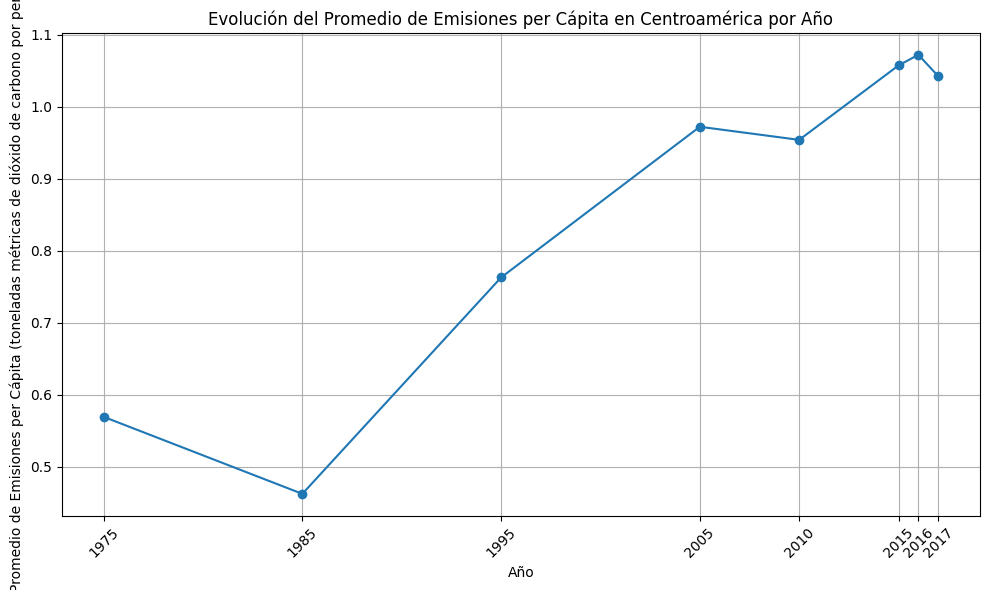

In [38]:
#Construye una **gráfica de líneas** usando `reporte_promedio_centroamerica` para mostrar la evolución del promedio de emisiones per cápita en Centroamérica por año.
#Debe incluir obligatoriamente:
#- título
#- eje X rotulado
#- eje Y rotulado
#- marcador visible

reporte_promedio_centroamerica = df_per_capita_es[df_per_capita_es['Pais'].isin(centroamerica1)].groupby('Anio')['Valor'].mean().reset_index()
reporte_promedio_centroamerica.rename(columns={'Valor': 'promedio_anio'}, inplace=True) 
plt.figure(figsize=(10, 6))
plt.plot(reporte_promedio_centroamerica['Anio'], reporte_promedio_centroamerica['promedio_anio'], marker='o')
plt.title('Evolución del Promedio de Emisiones per Cápita en Centroamérica por Año')
plt.xlabel('Año')
plt.ylabel('Promedio de Emisiones per Cápita (toneladas métricas de dióxido de carbono por persona)')
plt.xticks(reporte_promedio_centroamerica['Anio'], rotation=45)
plt.grid()
plt.tight_layout()
plt.show()



### Lectura del gráfico 1
Escribe aquí 1 oración explicando por qué este gráfico es útil y qué muestra.


Este grafico muestra el incremento de la contaminacion por persona en centroamerica y aunque a partir del anio 2016 empieza a bajar la contaminacion, hay un repunte muy alto desde 1985. Importante rescatar que se estan haciendo esfuerzos para bajar la contaminacion por persona.

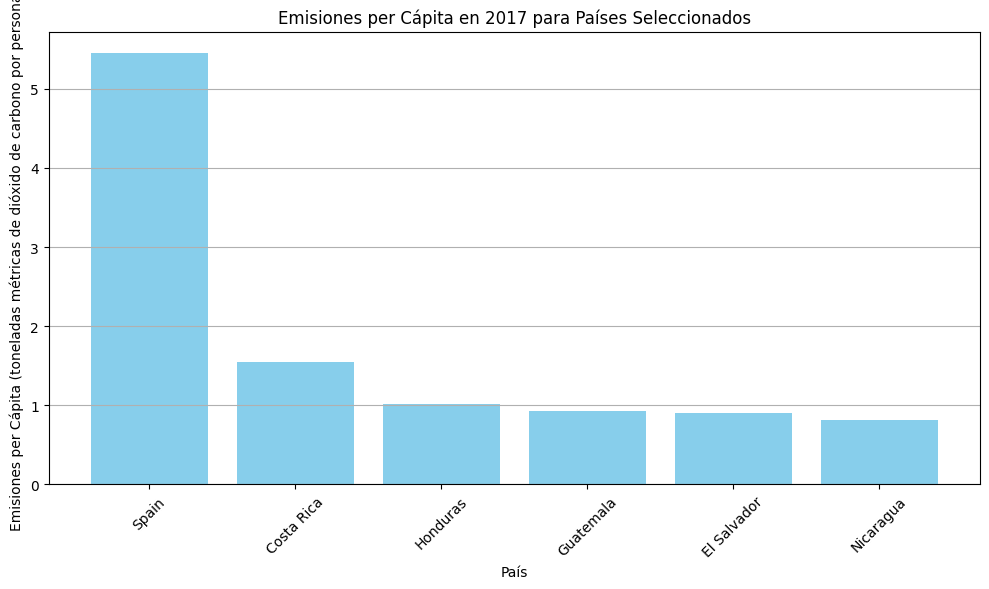

In [40]:
#Construye un **gráfico de barras** con las emisiones totales del año `2017` para estos países:
#- `Costa Rica`
#- `Guatemala`
#- `Honduras`
#- `El Salvador`
#- `Nicaragua`
#- `Spain`

#Debe incluir obligatoriamente:
#- título
#- eje X rotulado
#- eje Y rotulado

comparacion_2017 = comparar_paises(df_per_capita_es[df_per_capita_es['Anio'] == 2017], paises_comparar)[['Pais', 'Anio', 'Valor']].sort_values(by='Valor', ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(comparacion_2017['Pais'], comparacion_2017['Valor'], color='skyblue')
plt.title('Emisiones per Cápita en 2017 para Países Seleccionados')
plt.xlabel('País')
plt.ylabel('Emisiones per Cápita (toneladas métricas de dióxido de carbono por persona)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


Nos muestra que los paises centroamericanos tienen relativamente poca contaminacion con respecto a un grande como España, el nivel de contaminacion normalmente determina status y grandesa (Algo muy hironico) ya que espana es en tamanio mas grande que los paises centroamericanos pero tambien es un pais relativamente industrializado. Esto provoca que tengamos estos comportamientos de contaminacion.

### Lectura del gráfico 2
Escribe aquí 1 oración explicando por qué este gráfico es útil y qué muestra.


### Interpretación de gráficos del Bloque 5
Escribe aquí tus 3 a 4 líneas.


Los graficos nos indican informacion muy enriquesedora y a la vez preocupante. Nos muestran claramente la problematica en contaminacion que tenemos y como a crecido a lo largo de los anios, pero no todo es feo, se denotan repuntes a la baja y esto da alegria porque se hace conciencia de la situacion y los peligros que tenemos de frente. Por otro lado el segundo grafico pone a Costa Rica como el pais que mas contamina de centroameria (Siendo uno de los mas pequenios). Pero tambien muestra la enorme diferencia que existe entre centroamica y espana. probablemente si se suman los niveles de contaminacion de centroamerica y se comparan con espana puede que se llegue a contaminar lo mismo o hasta menos.

---
## Bloque 6 — Informe final crítico (20 pts)

### Objetivo
Cerrar el examen con una síntesis crítica basada en evidencia, no solo con una lista de resultados.

### Debes redactar un informe de 6 a 8 líneas que incluya obligatoriamente
- **2 hallazgos numéricos concretos**
- **1 limitación real del análisis**
- **1 comparación explícita entre emisiones totales y per cápita**
- **1 conclusión final** sobre el comportamiento de las emisiones en los países analizados
- **1 recomendación o advertencia final** basada en tus datos
- **coherencia clara** entre lo que exploraste, calculaste, graficaste y concluiste

### Regla importante
No describas solo resultados: explica qué significan.

### Nivel esperado
- **No logrado:** texto genérico sin cifras ni juicio analítico.
- **Inicial:** incluye alguna cifra, pero la conclusión es débil o desconectada.
- **Intermedio:** presenta hallazgos, limitación y conclusión coherente.
- **Logrado:** sintetiza, compara, limita e interpreta con evidencia concreta y criterio, y además propone una recomendación o advertencia defendible.


Hallazgos numericos concretos.

Hallazgos numericos concretos.
Costa Rica es el pais que mas contamina de centroamerica.
El porcentaje de contaminacion  del 85 a 2016 crecio exponencialmente

limitacion real del analisis.
No hay manera concreta de saber porque subieron tanto los niveles de contaminacien entre el 85 y el 2016

comparacion entre emisiones totales y per capita



### Informe final crítico
Escribe aquí tu informe de 6 a 8 líneas.


---
## Criterios de corrección visibles para el estudiante
- Se descontarán puntos si usas nombres distintos a los exigidos y eso dificulta la revisión.
- Se descontarán puntos si respondes con texto sin evidencia numérica.
- Se descontarán puntos si usas `pandas` para resolver lo que se pidió explícitamente con Python base.
- Se descontarán puntos si confundes emisiones totales con emisiones per cápita.
- Se descontarán puntos si generas gráficos sin título o sin ejes rotulados.
- Se reconocerá crédito parcial cuando el razonamiento sea correcto aunque el resultado final no sea exacto.
- Se valorará especialmente la coherencia entre exploración, análisis, gráficos e informe final.


## Checklist final de entrega
- [ ] Cargué y exploré el archivo correctamente.
- [ ] Expliqué qué representa una fila del dataset.
- [ ] Expliqué la diferencia entre emisiones totales y per cápita.
- [ ] Creé `df_trabajo`.
- [ ] Creé `df_totales_es` y `df_per_capita_es`.
- [ ] Creé `renombrar_columnas_es(df)` y `separar_por_tipo(df, tipo_emision)`.
- [ ] Escribí una `prediccion_inicial`.
- [ ] Creé `registros_totales`.
- [ ] Creé `resumen_pais(registros, pais)`.
- [ ] Construí `reporte_centroamerica_base`.
- [ ] Comparé mi predicción con la evidencia.
- [ ] Construí `reporte_total_centroamerica`.
- [ ] Construí `reporte_promedio_centroamerica`.
- [ ] Construí `conversiones_costa_rica`.
- [ ] Creé `comparar_paises(df, paises)`.
- [ ] Construí `comparacion_2017` y la usé como evidencia visible.
- [ ] Contrasté emisiones totales vs per cápita con un ejemplo concreto.
- [ ] Generé los 2 gráficos.
- [ ] Expliqué por qué cada gráfico era útil.
- [ ] Escribí el informe final crítico con recomendación o advertencia.
